THIS PROGRAM EXPLORES THE USE OF A BASIC PINN DESIGN TO COMPARE AGAINST AN ANALYTIC SOLUTION TO AN ORDINARY DIFF EQN: Y''+PI^2*SIN(PI*X)

In [1]:
#Importing the necessary libraries:
import tensorflow as tf
import numpy as np
import math as mt
import matplotlib.pyplot as plt

In [2]:
# Creating the PINN model architecture for later use:
def create_model():
    model= tf.keras.Sequential();
    model.add(tf.keras.layers.Dense(128,activation="tanh",name="layer_1"));
    model.add(tf.keras.layers.Dense(64,activation="tanh",name="layer_2"));
    model.add(tf.keras.layers.Dense(32,activation="tanh",name="layer_3"));
    model.add(tf.keras.layers.Dense(1,activation=None,name="output_layer")); # Becasue only one y(x) value is being evaluated for a given x.

    return model

In [3]:
#Calling the model to process on the input data in a layer by layer outputting manner and produce a predicted value:
def call_model(model,x):
    x=model.get_layer("layer_1")(x);
    x=model.get_layer("layer_2")(x);
    x=model.get_layer("layer_3")(x);
    y_pred=model.get_layer("output_layer")(x);

    return y_pred

In [4]:
# Creating the pde function to calculate the derivative terms and return the residual of the ODE: y''+(pi**2)*sin(pi*x) = 0, 
#considering the 2nd derivative of y_pred:
def pde(model,x):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x); # x here is an outside tensor value which needs to be explicitely watched.
        y_pred=call_model(model,x); # Further used in computational flow in y' evaluation.
        y_x=tape.gradient(y_pred,x); # Further used in the computational flow in y'' value
            
    y_xx=tape.gradient(y_x,x); # this is not used for further differentiation, therefore doesnt come ubder the gradientTape recording session.
    
    y_xx=tf.cast(y_xx,tf.float32); #typecasting tensor object to float32 type for prevention of mathematical inconsistencies in furthur bodies. 
    
    del tape; #For preventing data leakage during long training runs, since for persistent=True the tape memeory remembers the old values for as long as tape exists
    
    return y_xx+tf.cast((3.14)**2*tf.sin(3.14*x),tf.float32)    

In [5]:
#Creating a loss function for calculating the net loss result considering the pde_loss and the bc_loss: 
def loss(model,x,x_bc,y_bc):
    res_pde=pde(model,x); #residual for partial diff equation/ordinary diff eqn
    y_pred_bc=call_model(model,x_bc); #output for the model computation used in the loss residual def

    # Force conversion to float data types for all values under the loss function:
    res_pde=tf.cast(res_pde,tf.float32);
    
    loss_pde=tf.reduce_mean(tf.square(res_pde)); #the right MSE usage in SCIML--> tf.reduce_mean(tf.square())
    loss_bc=tf.reduce_mean(tf.square(y_pred_bc-y_bc));

    return loss_pde+loss_bc

In [6]:
#Creating an optimzer structure with a learning schedule for further development of various other code bodies -- in 'train_model_step' and others:
learning_schedule= tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.0005, # l_0
    decay_steps=1000, # n_steps for entire staircase width--> after n_steps, the learning rate decays by the below rate factor once
    decay_rate=0.96, #alpha
    staircase=True # l0*alpha*floor(step/n_steps)=new_learning_rate --> discrete values and not continuous.
)
optimizer=tf.keras.optimizers.Adam(
    learning_rate=learning_schedule,
    beta_1=0.9, # For the mean of the gradients : m  = beta_1·m  + (1−beta_1)·gradient_current
    beta_2=0.99, # For the variance of the gradients: v=  beta_2·v  + (1−beta_2)·gradient_current²
    epsilon=1e-7, # For taking care of divison by 0 in the updates of the trainable variables: theta  = theta − learn_rate * m̂ / (√v̂ + ε) --> parameter update
    clipnorm=1.0 # For rescaling the entire gradient vector of gradients before apply.gradient() function for hyperparameter tuning 
)

In [7]:
#Creating a function for training the model on the data per epoch iteration:
def train_model_step(model,x_train,x_bc,y_bc):
    with tf.GradientTape() as tape:
        y_pred=call_model(model,x_train); # Coming under the recording envelope of GradientTape class, y_pred and loss are being watched.
        loss_val=loss(model,x_train,x_bc,y_bc);

    grads=tape.gradient(loss_val,model.trainable_variables); # Backpropagation to find the gradients of the loss function with the trainable values (theta) of the model
    
    optimizer.apply_gradients(zip(grads,model.trainable_variables)); #optimzing/tuning the trainable variables (hyperparameters) using the gradients so obtained from the loss function def.

    loss_fin=loss_val;
    return loss_fin

MAIN BODY FOR THE CORE PINN LOGIC FLOW:

In [8]:
#Forming the data set for the input main values x, and boundary values, x_bc, y_bc:
x_initial=np.linspace(-1,1,300).reshape(-1,1);
x_train=tf.convert_to_tensor(x_initial);

x_bc=np.array([[-1.0],[1.0]],dtype=np.float32);
y_bc=np.array([[0],[0]],dtype=np.float32);
x_bc=tf.convert_to_tensor(x_bc); #To be used as tensor objects in further train_model_step() functions.
y_bc=tf.convert_to_tensor(y_bc);

#Making the model and storing it in an object:
model=create_model();

epoch=1000; #Define epoch run iterations

for epoch_iter in range(epoch):
    loss_val=train_model_step(model,x_train,x_bc,y_bc);
    #Outputting only limited iterations since epoch can go to thousands of iterations.
    if epoch_iter == 0 or (epoch_iter) % 100 == 0 or epoch_iter == epoch-1: 
        print(f"For iteration: {epoch_iter} the loss value: {loss_val.numpy()} \n");    


For iteration: 0 the loss value: 48.509620666503906 

For iteration: 100 the loss value: 1.4350011348724365 

For iteration: 200 the loss value: 0.012061296962201595 

For iteration: 300 the loss value: 0.003490770934149623 

For iteration: 400 the loss value: 0.0014784600352868438 

For iteration: 500 the loss value: 0.000664750870782882 

For iteration: 600 the loss value: 0.0007233491633087397 

For iteration: 700 the loss value: 0.0007224425207823515 

For iteration: 800 the loss value: 0.0012904476607218385 

For iteration: 900 the loss value: 0.000784824718721211 

For iteration: 999 the loss value: 0.00021956567070446908 



In [9]:
#Testing values on the PINN model:
x_test=np.linspace(-1,1,500).reshape(-1,1);
x_test=tf.convert_to_tensor(x_test);
y_pred=call_model(model,x_test).numpy(); #prediction from test values fed into model

y_true=tf.sin(np.pi*x_test); #Analytic solution for comparison

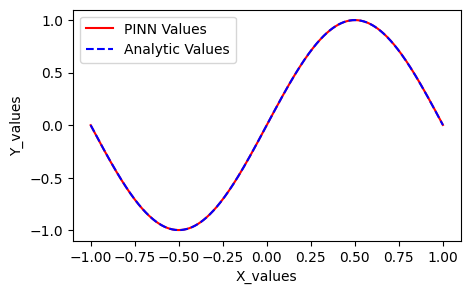

In [10]:
#For plotting the outputs of the PINN compariosn with actual analytic solution:
plt.figure(figsize=(5,3));
plt.plot(x_test,y_pred,'r',label='PINN Values');
plt.plot(x_test,y_true,'b--',label='Analytic Values');
plt.legend(loc="upper left");
plt.xlabel('X_values');
plt.ylabel('Y_values')
plt.show();